# Data Structures & Algorithms
# Group Project 2
## Q2: Letters & Word Analysis

### Preprocessing

In [1]:
# Import all dependencies
import re
import string
import math
import collections
import itertools
import wordcloud
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/amberteetsel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Preprocessing Function for a Gutenberg Project Book
def process_book(og_text_file, start_marker, end_marker):

    # Read full text file
    with open(og_text_file, "r", encoding="utf-8") as file:
        book = file.read()

    # Separate main text from Gutenberg markers
    if start_marker in book and end_marker in book:
        main_text = book.split(start, 1)[1].split(end, 1)[0].strip()
    else:
        raise ValueError("Start or end marker not found")

    # Convert to lowercase
    main_text = main_text.lower()

    # Remove punctuation, digits, and special characters using regular expressions
    # Code below keeps only letters
    clean_text = re.sub(r'[^a-zA-Z\s]', '', main_text)

    # Get rid of newlines, extra whitepsace
    clean_text = re.sub(r"\s+", " ", clean_text).strip()
    # print(clean_text[:2500])

    # Write to new clean file
    with open(output, "w", encoding="utf-8") as new_file:
        new_file.write(clean_text)

    # Output clean text
    return clean_text

# Tokenize by whitespace
def tokenize(text):
    tokens = text.strip().split()
    return tokens

# Remove stopwords using nltk
def remove_stopwords(tokens):
    stop_words = set(stopwords.words('english'))

    # Remove punctuation/digits/special characters to match our format
    clean_stop_words = [re.sub(r'[^a-zA-Z\s]','', word) for word in list(stop_words)]

    words = [t for t in tokens if t not in clean_stop_words]
    
    # get rid of word 'chapter' (so ToC does not affect word analysis)
    ## This word does appear within the main body of the novel but word is not frequent enough to significantly affect analysis
    lw = [word for word in words if word != "chapter"]
    
    return lw, clean_stop_words

In [3]:
# Define file names
input_txt = "TextFiles/Little_Women_Full.txt"
output = "TextFiles/Little_Women.txt"

# Markers for start/end of actual novel
start = "*** START OF THE PROJECT GUTENBERG EBOOK LITTLE WOMEN ***"
end = "*** END OF THE PROJECT GUTENBERG EBOOK LITTLE WOMEN ***"

clean_text = process_book(input_txt, start, end)

tokens = tokenize(clean_text)

lw = remove_stopwords(tokens)[0]

##### Summary of Preprocessing Effects

In [4]:
# Tokens before stopword removal
n_tokens = len(tokens)
print(f"Original Token Count: {n_tokens:,}")
# Tokens after stopword removal
n_lw = len(lw)
print(f"Post-Processing Token Count: {n_lw:,}")
print(f"Percent of Tokens Removed: {(n_tokens-n_lw)/n_tokens:.2%}")

Original Token Count: 186,088
Post-Processing Token Count: 90,565
Percent of Tokens Removed: 51.33%


### Outputs

#### Letter Frequencies

Alphabetical        By Frequency       
         Letter  Count       Letter  Count
0             a  62921            e  95978
1             b  12158            t  66827
2             c  15837            a  62921
3             d  37501            o  59526
4             e  95978            n  51465
5             f  17291            i  50701
6             g  17395            h  48428
7             h  48428            s  47166
8             i  50701            r  45232
9             j   2288            d  37501
10            k   7577            l  34862
11            l  34862            u  22758
12            m  19825            m  19825
13            n  51465            w  18515
14            o  59526            y  18040
15            p  13073            g  17395
16            q    772            f  17291
17            r  45232            c  15837
18            s  47166            p  13073
19            t  66827            b  12158
20            u  22758            k   7577
21            v   7041            v   7041
22            w  18515            j   2288
23            x    881            x    881
24            y  18040            q    772
25            z    290            z    290

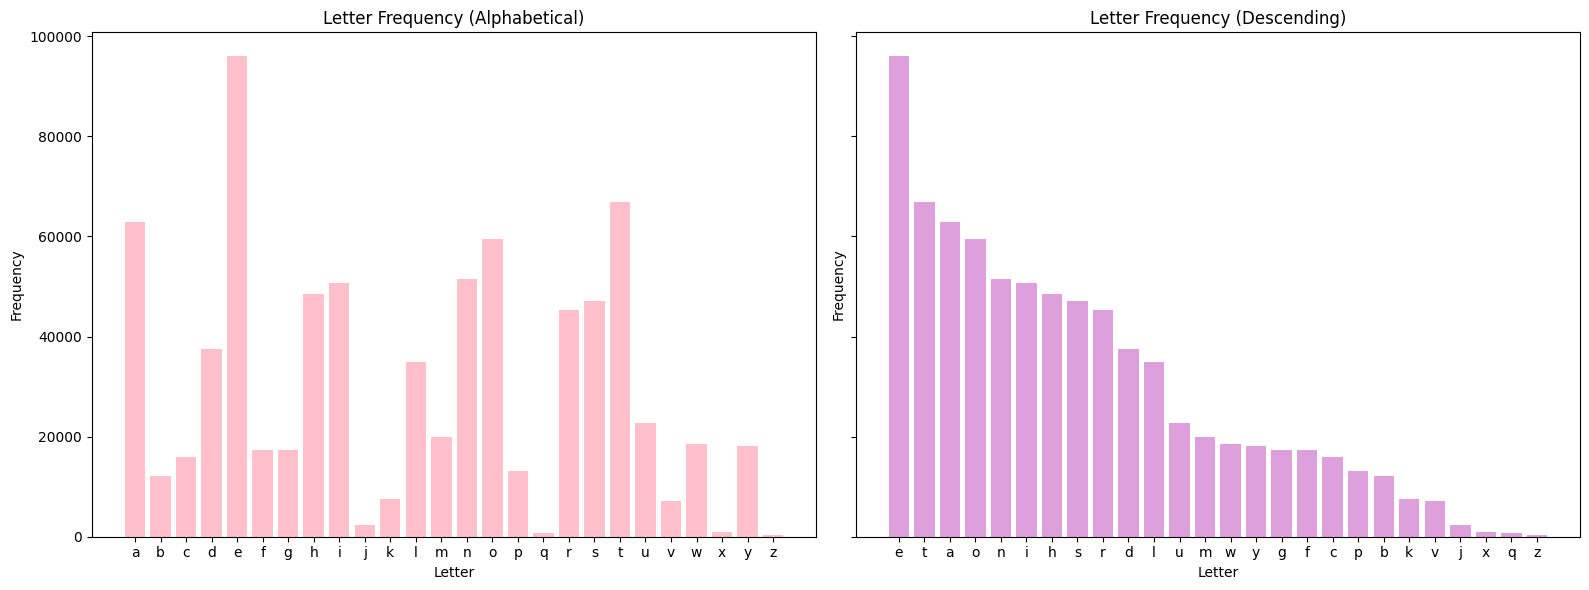

<Figure size 640x480 with 0 Axes>

In [5]:
# Get counts
counts = collections.Counter(clean_text)
# Remove whitespace entry
counts.pop(' ', None)
# All letters a-z
az = list(string.ascii_lowercase)
freq = [counts.get(l,0) for l in az]

# DataFrames
df = pd.DataFrame({'Letter':az, 'Count':freq})
df_sorted = df.sort_values(by='Count', ascending=False).reset_index(drop=True)
dfs = pd.concat([df, df_sorted], axis=1, keys=['Alphabetical', 'By Frequency'])
display(dfs)

# Bar Charts
fig, ax = plt.subplots(1,2,figsize = (16,6),sharey=True)

## Alphabetical
ax[0].bar(df.Letter, df.Count, color='pink')
ax[0].set_title('Letter Frequency (Alphabetical)')
ax[0].set_xlabel('Letter')
ax[0].set_ylabel('Frequency')

## By Frequency
ax[1].bar(df_sorted.Letter, df_sorted.Count, color='plum')
ax[1].set_title('Letter Frequency (Descending)')
ax[1].set_xlabel('Letter')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
plt.savefig('Images/letter_count_bar.png')

#### Word Frequencies (after stopword removal)

,Word,Frequency
0,jo,1247
1,said,826
2,little,725
3,one,702
4,meg,633
5,like,583
6,amy,571
7,laurie,547
8,would,444
9,good,430


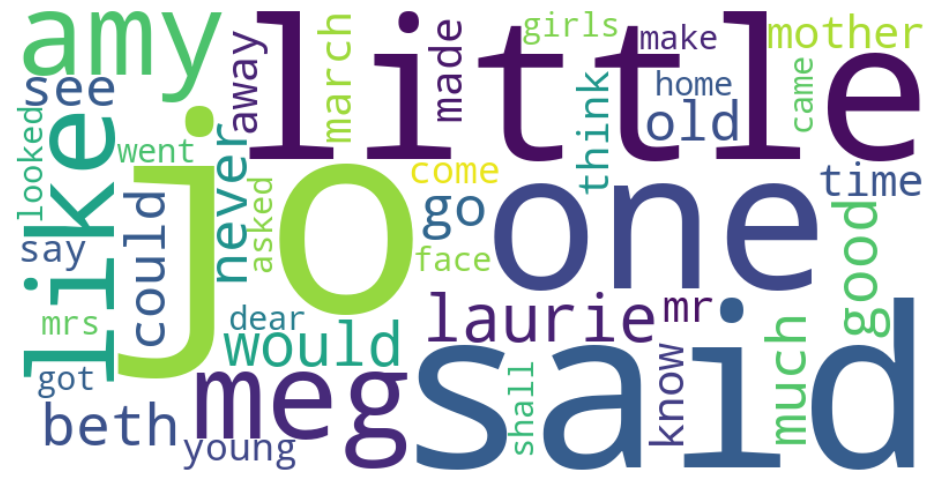

<Figure size 640x480 with 0 Axes>

In [6]:
word_counts = collections.Counter(lw)

top40 = word_counts.most_common(40)

df_words = pd.DataFrame(top40, columns=['Word', 'Frequency'])
display(df_words)

# Word Cloud
wc = wordcloud.WordCloud(width=800, height=400, background_color='white', colormap='viridis')
wc.generate_from_frequencies(dict(top40))
plt.figure(figsize=(14,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()
plt.savefig('Images/word_cloud.png')

#### Bigrams & Trigrams

In [7]:
# Tokenize clean version of text so we have each word individually, though this will include stopwords
book = tokenize(clean_text)

clean_stop_words = remove_stopwords(tokens)[1]

# Use itertools to offset list of words by 1 (for bigrams) or 2 (for trigrams) and zip consecutive words together
bigrams = list(zip(book, book[1:]))
trigrams = list(zip(book, book[1:], book[2:]))

# Filter out entries containing stopwords (avoids things like "to the", "i am", etc.)
bigrams_clean = [bg for bg in bigrams if sum(1 for w in bg if w in clean_stop_words) == 0]
trigrams_clean = [tg for tg in trigrams if sum(1 for w in tg if w in clean_stop_words) < 1]

# Get frequencies
bicounts = collections.Counter(bigrams_clean)
tricounts = collections.Counter(trigrams_clean)

# Top 20
bi20 = bicounts.most_common(20)
tri20 = tricounts.most_common(20)

df_bi = pd.DataFrame(bi20, columns=['Bigram', 'Frequency'])
df_tri = pd.DataFrame(tri20, columns=['Trigram', 'Frequency'])

df_bitri = pd.concat([df_bi, df_tri], axis=1, keys=['Bigrams', 'Trigrams'])

# display(df_bi)
# display(df_tri)
display(df_bitri)

Bigrams                           Trigrams          
              Bigram Frequency                  Trigram Frequency
0       (mrs, march)       142       (said, mrs, march)        25
1         (said, jo)       118     (said, meg, looking)         7
2      (aunt, march)        76       (said, mr, brooke)         7
3        (said, meg)        75       (mrs, march, said)         6
4     (mr, laurence)        67      (old, mr, laurence)         6
5       (mr, brooke)        59    (said, jo, decidedly)         6
6        (mr, bhaer)        57      (asked, mrs, march)         6
7        (said, amy)        56      (said, jo, looking)         5
8        (cried, jo)        51     (mrs, march, looked)         5
9   (old, gentleman)        50      (bad, effect, upon)         5
10    (said, laurie)        47     (mr, brooke, looked)         5
11       (old, lady)        37     (love, one, another)         5
12    (one, another)        36  (falling, summer, rain)         5
13     (young, lady)        34    (replied, mrs, march)         4
14       (asked, jo)        34      (cried, jo, taking)         4
15      (every, day)        31     (mrs, march, smiled)         4
16      (said, beth)        30  (said, laurie, looking)         4
17   (young, ladies)        30       (door, flew, open)         4
18       (said, mrs)        28     (said, mr, laurence)         4
19       (mr, march)        26        (new, years, eve)         3

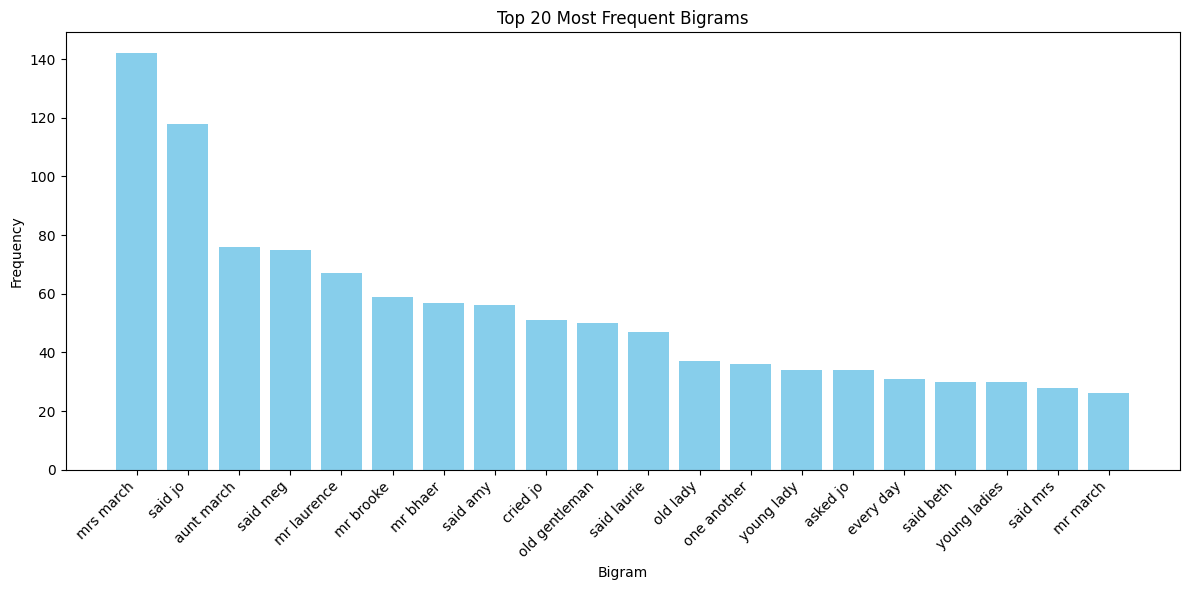

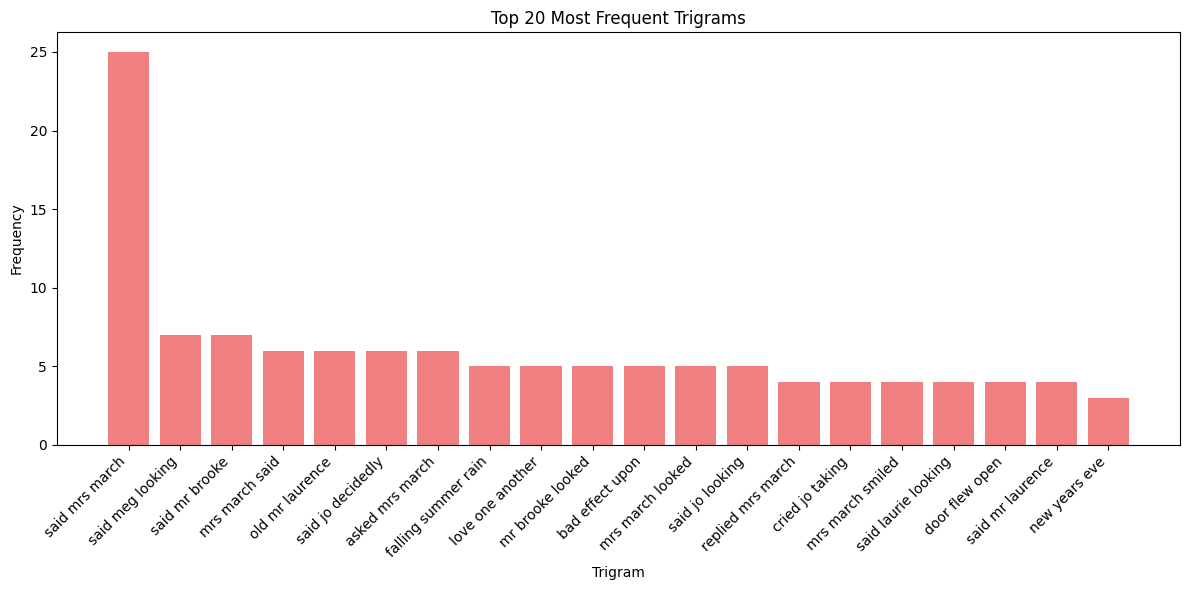

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df_bi['Label'] = df_bi['Bigram'].apply(lambda x: ' '.join(x))

plt.figure(figsize=(12, 6))
# Sort data by Frequency in descending order for plotting
df_bi = df_bi.sort_values(by='Frequency', ascending=False)
plt.bar(df_bi['Label'], df_bi['Frequency'], color='skyblue')
plt.xlabel('Bigram')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Bigrams')
# Rotate x-axis labels for readability, aligning to the right (ha='right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.savefig('Images/bigrams_bar_chart.png')
plt.close()

# --- Trigrams Bar Chart ---

df_tri['Label'] = df_tri['Trigram'].apply(lambda x: ' '.join(x))

plt.figure(figsize=(12, 6))

df_tri = df_tri.sort_values(by='Frequency', ascending=False)
plt.bar(df_tri['Label'], df_tri['Frequency'], color='lightcoral')
plt.xlabel('Trigram')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Trigrams')
# Rotate x-axis labels for readability, aligning to the right (ha='right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.savefig('Images/trigrams_bar_chart.png')
plt.close()

### Discussion

#### Big-O Complexity of Preprocessing

Let $L$ be the total number of characters in the text, and let $N$ be the total number of words/items in a list:

- Reading Text File

    - Time Complexity $O(L)$
    - Space Complexity $O(L)$: Must store entire text in memory   <br><br>

- Extract Main Text

    - Time Complexity $O(L)$: Scan through full text to find specific substrings
    - Space Complexity $O(L)$   <br><br>
 
- Convert to Lowercase

    - Time Complexity $O(L)$: Creating the lowercase version is proportional to the string length   <br><br>
 
- Regex Cleaning

    - Time Complexity $O(L)$: Regular expression substitution is typically linear with respect to the input string length
    - Space Complexity $O(L)$: Must store the characters to reconstruct   <br><br>

- Whitespace Cleanup

    - Time Complexity $O(L)$: Splitting the string into tokens is proportional to the string length
    - Let $N$ be the number of tokens/words, then $N \le L$   <br><br>
 
- Tokenization

    - Time Complexity $O(L)$: Scan each character once to find whitespaces to split
    - Space Complexity $O(N)$: Store a list of words   <br><br>

- Stopword Cleanup

    - Time Complexity $O(N)$ or $O(1)$: Proportional to the number of stopwords
    - The `nltk` library's english stopwords list contains $\approx 200$ words so we can assume constant time in this case, or $O(1)$   <br><br>

- Stopword Filtering

    - Time Complexity $O(N)$: Iterating through $N$ tokens and performing hash-based lookups in the set (clean_stop_words)   <br><br>

##### Since $N \le L$ (the number of words is less than or equal to the number of characters) and all major sequential processing steps are $O(L)$ or $O(N)$, the overall time complexity of the code is $O(L)$, making it very efficient for processing large text files. Space Complexity is also $O(L)$ because any temporary data is proportional to the size of the text.

#### Big O Complexity of Counting

Let $N$ be the number of total words in our final tokenized list or the number of total characters in a text file, depending on the scenario.

The time complexity of the provided code is dominated by the initial counting and sorting steps.The overall time complexity is $O(N)$, where $N$ is the total number of words in the input list lw.The complexity is linear because the most intensive operations depend directly on the size of the input list of words ($N$), while the subsequent steps operate on a fixed, small number of items (40).

    - `collections.Counter(list_of_words_or_text)` has time complexity of $O(N)$ because it needs to check every word, and space complexity of $O(\leq N)$ because it only stores the unique words
    - `most_common(40)` has time complexity of $O(N)$ and space complexity of $O(1)$ because 40 is a constant.
    - At this stage we're working with a small list of 40 words/letters and all operations have complexity of either $O(N)$ or $O(1)$

Overall Time & Space Complexity: $O(N)$

#### Interpretation of Text Distributions:

1) Letter Frequency

   'e' is the most frequently occurring letter, consistent with the Cornell Department of Mathematic's English Letter Frequency Table.

   Cornell's data shows that 'v', 'k', 'x', 'q', 'j', and 'z' are the least common letters in the English language. *Little Women* largely follows this pattern but diverges on the letter 'j'. Their data has 'j' occurring at $0.1 \%$ overall.


   In contrast, this analysis finds that 'j' occurs at $\approx 0.3\%$, three times more frequently than in the English language as a whole. This can be explained by the fact that the main character's name is Jo and that is the most frequently used word in the novel (see below).

3) Word Frequency (after additional stopword removal)

   The most frequent word in *Little Women* is "Jo", the name of our protagonist, with 1,247 references. Appropriately, the top 10 most frequent words also include "Meg" (633), "Amy" (571), "Laurie" (547), "Beth" (414), and "Mother" (328); these are the names of the other main characters (excluding Mr. March/Father, to be discussed below). Jo's prescence in the text is double or more than that of her other sistesr. It's interesting that "Beth" is referenced the least among the March Sisters - the character passes away in the middle of the novel, but her preceding illness is oft talked about among the family and neighbors. However, Beth has the least conflict with her sisters which could explain why her name is the least-frequently referenced among the four.

   The second most frequent word is aptly part of the novel's title, "little" with 725 instances. "Women", however, only appears 44 times. The name "Laurie" is the 4th-most common word, which is also expected given he is Jo's best friend and love interest.

   
5) Bigram analysis

   Among the top 40 bigrams, 'mrs march' has the highest frequency of occurrence (142) and 'mr march' has lowest frequency of occurrence (26). This makes sense as these characters are among the only referenced by their full title/name. Mr. March is absent for most of the book, explaining why he has fewer references than Mrs. March.

6) Trigram Analysis

   Trigram '(said, mrs, march)' has highest frequency of occurrence (25). As discussed in Part 4, Mrs. March is one of the only characters referred to by two separate words instead of just a first or last name. Therefore it makes sense that her dialogue (or any other reference to her) would come up more often in trigrams.

   Trigram '(new, years, eve)' has lowest frequency of occurrence (3).

Reference: [Cornell Department of Mathematic's English Letter Frequency Table](https://pi.math.cornell.edu/~mec/2003-2004/cryptography/subs/frequencies.html)